In [1]:
import torch
import numpy as np
import Modules.preprocess as pp


#This defines where the data is
data  = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(300, 303, 1)
train_beams = list(range(0, 32))

#This generates the data
train_data = pp.data_gen(data, beams = train_beams, frames=frames, splits =.99)
train_dataloader, q  = train_data.get_dataloaders(train_data, batch_size=1, num_workers=4)




In [2]:
ins , outs = next(iter(train_dataloader))

In [18]:
x = ins.reshape(-1, 3).numpy()[:,0]
y = ins.reshape(-1, 3).numpy()[:,1]
z = outs.reshape(-1).numpy()

In [28]:
print(x.shape, y.shape, z.shape)

x = x.astype(np.complex64)
y = y.astype(np.complex64)
z = z.astype(np.float32)

(17449,) (17449,) (17449,)


In [29]:
import numpy as np
import finufft

# Sort by z
idx = np.argsort(z)
z, x, y = z[idx], x[idx], y[idx]

# NUFFT requires points in [-pi, pi]
z_scaled = ((z - z.min()) / (z.max() - z.min()) * 2 * np.pi - np.pi)

N = len(z)

# Type 1 NUFFT: non-uniform points → uniform frequency grid
X_freq = finufft.nufft1d1(z_scaled, x, N)
Y_freq = finufft.nufft1d1(z_scaled, y, N)

freqs = np.fft.fftfreq(N, d=(z.max() - z.min()) / N)

In [44]:
print(freqs.std())

971.4738706536542


c:\Users\dculv\miniconda3\envs\Ocean_Waves\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\dculv\miniconda3\envs\Ocean_Waves\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


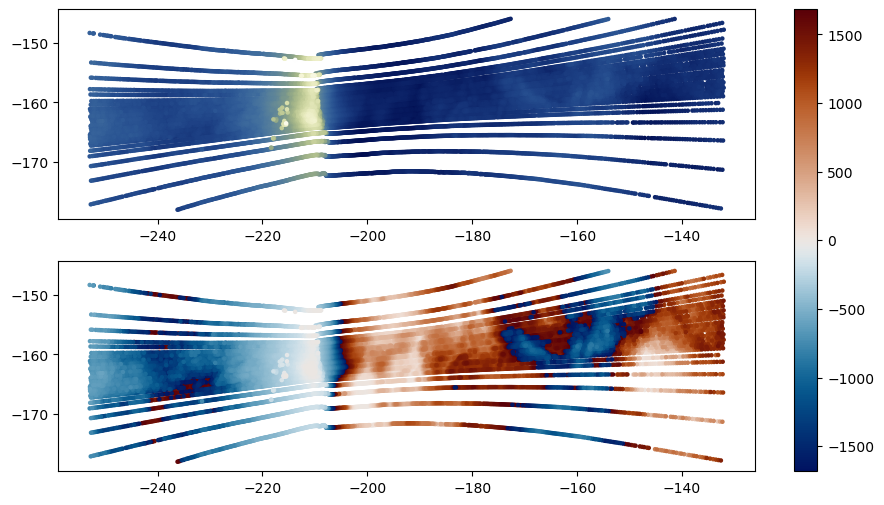

In [42]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc


fig, (ax1, ax2) = plt.subplots(2, figsize = (10,6))
ax1.scatter(x,y,c = z, cmap = cmc.davos, s = 5)

sc2 = ax2.scatter(x,y,c = freqs, cmap = cmc.vik, s = 5)
cbar = fig.colorbar(sc2, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)


plt.show()